In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN  

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\forecasting_feature_set.csv')

df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

drop_cols = [
    'net_load_lag_1h', 'net_load_lag_24h',
    'demand_lag_1h', 'demand_lag_24h',
    'wind_gen_lag_24h'
]
df_tcn = df.drop(columns=drop_cols, errors='ignore')

split_index = int(len(df_tcn) * 0.8)
train_df = df_tcn.iloc[:split_index]
test_df  = df_tcn.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']
X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(seq_length, len(X)):
        Xs.append(X[i-seq_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQ_LENGTH = 48  # 12 hours of context at 15-min intervals

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

# TCN MODEL DEFINITION
# nb_filters: Number of convolutional filters
# kernel_size: The size of the sliding window
# dilations: Exponentially increasing receptive field
model = Sequential([
    TCN(input_shape=(SEQ_LENGTH, X_train_seq.shape[2]),
        nb_filters=64,
        kernel_size=3,
        nb_stacks=1,
        dilations=[1, 2, 4, 8, 16, 32],
        padding='causal',
        use_skip_connections=True,
        dropout_rate=0.2,
        return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

y_pred_scaled = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_seq).flatten()

c:\Users\Hp\anaconda3\Lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_1 (TCN)                     │ (None, 64)             │       144,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,305 (571.50 KB)

 Trainable params: 146,305 (571.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - loss: 0.0908 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0037 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 3/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - loss: 0.0018 - val_loss: 9.1093e-04 - learning_rate: 0.0010
Epoch 4/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0011 - val_loss: 5.5872e-04 - learning_rate: 0.0010
Epoch 5/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - loss: 6.9797e-04 - val_loss: 5.8637e-04 - learning_rate: 0.0010
Epoch 6/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - loss: 4.6159e-04 - val_loss: 4.3111e-04 - learning_rate: 0.0010
Epoch 7/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 652s 551ms/step - loss: 3.1785e-04 - val_loss: 2.9296e-04 - learning_rate: 0.0010
Epoch 8/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - loss: 2.4447e-04 - val_loss: 2.4919e-04 - learning_rate: 0.0010
Epoch 9/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 60s 

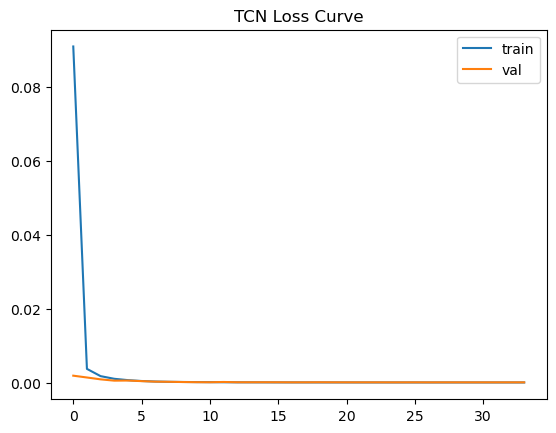

In [3]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("TCN Loss Curve")
plt.show()

In [4]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)
epsilon = 1e-6
mape = np.mean(np.abs((y_test_actual - y_pred) / (y_test_actual + epsilon))) * 100

print("\nTCN PERFORMANCE METRICS")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test_actual - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")


TCN PERFORMANCE METRICS
RMSE : 387.7851
MAE  : 284.9173
R²   : 0.9961
MAPE : 1.58%

Error Summary:
Mean Error      : 85.3130
Std Error       : 378.2843
Max Error       : 3558.6120


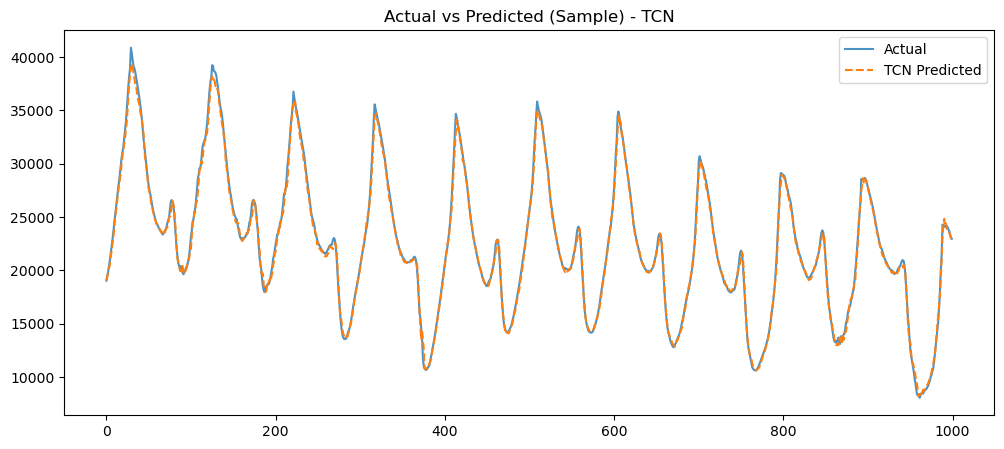

In [5]:
start, end = 10000, 11000

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[start:end], label="Actual", alpha=0.8)
plt.plot(y_pred[start:end], label="TCN Predicted", linestyle='--')
plt.title("Actual vs Predicted (Sample) - TCN")
plt.legend()
plt.show()

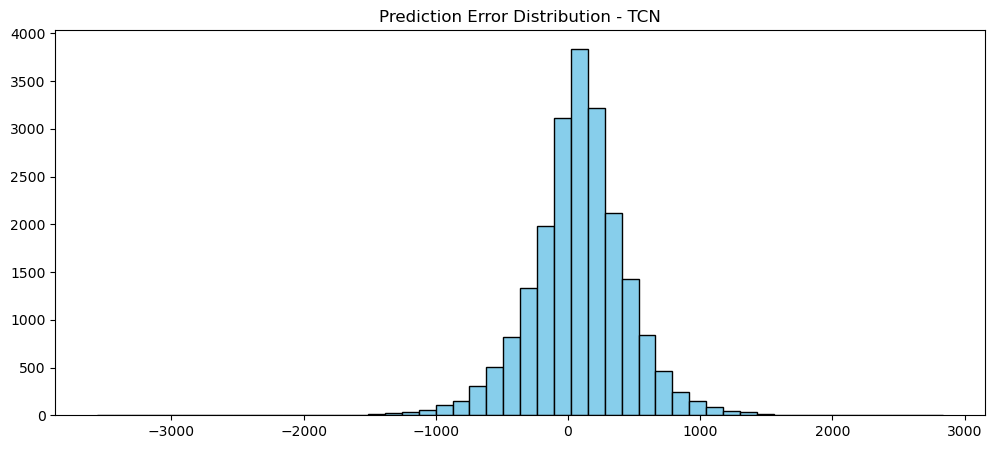

In [6]:
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Error Distribution - TCN")
plt.show()

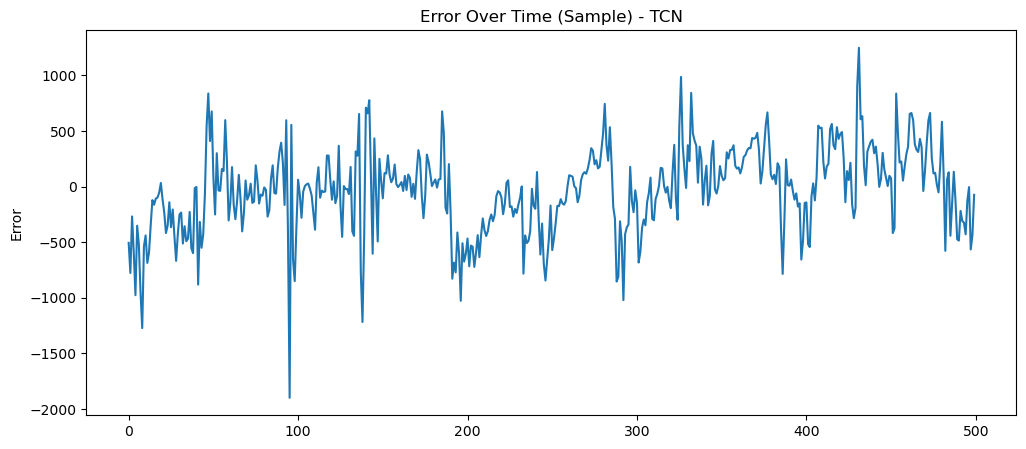

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(errors[:500])
plt.title("Error Over Time (Sample) - TCN")
plt.ylabel("Error")
plt.show()